<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Glass/incremental_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Glass/'

# fixed seed while the code is built and tested - the actual sweep
# will loop over multiple seeds per architecture
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
# load the split we froze in modelling_prep - never regenerate it
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "Type"]

X_train, y_train = train_df[feature_cols], train_df["Type"]
X_val, y_val = val_df[feature_cols], val_df["Type"]
X_test, y_test = test_df[feature_cols], test_df["Type"]

# scale - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# encode labels by minority -> majority rank, fixed across the whole project
MINORITY_TO_MAJORITY_LABELS = [6, 5, 3, 7, 1, 2]  # tableware, containers, vehicle_float, headlamps, bldg_float, bldg_nonfloat
CLASS_NAMES = {1: "bldg_float", 2: "bldg_nonfloat", 3: "vehicle_float",
               5: "containers", 6: "tableware", 7: "headlamps"}
label_to_index = {label: i for i, label in enumerate(MINORITY_TO_MAJORITY_LABELS)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 136  Val: 34  Test: 43
{6: 0, 5: 1, 3: 2, 7: 3, 1: 4, 2: 5}


# Convet to tensors

In [ ]:
# torch wants float32 for inputs and long (int64) for class indices
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([136, 9]) torch.Size([136])


# Defining a growable network

In [ ]:
class GrowableNet(nn.Module):
    """
    A network that can grow one hidden neuron or one output class at a
    time, keeping all previously learned weights.

    Structure: a permanent direct input->output ("skip") connection,
    plus an optional growing hidden pathway layered on top. The skip
    connection is what makes growing from 0 to 1 hidden neuron safe -
    a new hidden neuron's contribution to the output starts at exactly
    zero, so the network computes the same thing right after growing
    as it did right before. Training then decides whether the new
    pathway is worth using.
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.fc_skip = nn.Linear(input_dim, output_dim)  # always present, never discarded

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_hidden_out = None
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_hidden_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fc_skip(x)
        if self.hidden_dim > 0:
            h = torch.tanh(self.fc_hidden(x))
            out = out + self.fc_hidden_out(h)
        return out

    def add_hidden_neuron(self):
        """Grow the hidden pathway by one neuron. fc_skip is untouched.
        Existing hidden neurons keep their weights; the new neuron's
        output contribution is initialised at zero, so growing starts
        as a no-op."""
        if self.hidden_dim == 0:
            new_fc_hidden = nn.Linear(self.input_dim, 1)
            new_fc_hidden_out = nn.Linear(1, self.output_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight.zero_()
                new_fc_hidden_out.bias.zero_()
            self.fc_hidden = new_fc_hidden
            self.fc_hidden_out = new_fc_hidden_out
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_hidden_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_hidden_out.weight[:, :old_dim] = self.fc_hidden_out.weight
            new_fc_hidden_out.weight[:, old_dim:] = 0.0  # new neuron starts silent
            new_fc_hidden_out.bias[:] = self.fc_hidden_out.bias
        self.fc_hidden_out = new_fc_hidden_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class, on both pathways. All
        existing weights are kept; only the new class's weights are
        freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1

        new_fc_skip = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_skip.weight[:old_dim] = self.fc_skip.weight
            new_fc_skip.bias[:old_dim] = self.fc_skip.bias
        self.fc_skip = new_fc_skip

        if self.hidden_dim > 0:
            new_fc_hidden_out = nn.Linear(self.hidden_dim, new_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight[:old_dim] = self.fc_hidden_out.weight
                new_fc_hidden_out.bias[:old_dim] = self.fc_hidden_out.bias
            self.fc_hidden_out = new_fc_hidden_out

        self.output_dim = new_dim

# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active ata given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights with a best_state safeguard added

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Live diagnosis function

In [ ]:
def diagnose_incremental(curr_val_loss, curr_no_skill, history, best_epoch,
                          prev_val_loss=None, prev_stage_final_ratio=None,
                          min_relative_improvement=0.02, ratio_margin=0.05,
                          diverge_delta=0.01, underfit_ratio=0.8):
    """
    Live, backward-only diagnosis - never looks at architectures that
    haven't been trained yet. Three cases, in order of preference:

    1. Not the first architecture tried in this stage (prev_val_loss given):
       did adding the last neuron reduce val loss by at least a fixed
       *relative* fraction? Using a relative (not absolute) threshold
       here matters because raw loss values grow as more classes become
       active, so a fixed absolute threshold gets harder to clear at
       later stages purely from scale, not from genuinely needing less
       capacity - this was found empirically to bias the algorithm
       toward stopping growth too early in later stages.
    2. First architecture in a stage after stage 1 (prev_stage_final_ratio
       given): compare this stage's starting ratio (val loss / no-skill,
       for this stage's classes) against how good the ratio was right
       before this class was added. Already scale-normalized via no-skill.
    3. Truly the first thing ever tried, stage 1, nothing to compare
       against at all - the only case using the absolute no-skill check.
    """
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    is_overfitting_trend = (final_val > val_loss + diverge_delta) and (final_train < train_loss)

    if prev_val_loss is not None:
        relative_improvement = (prev_val_loss - curr_val_loss) / prev_val_loss
        if relative_improvement > min_relative_improvement:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if prev_stage_final_ratio is not None:
        curr_ratio = curr_val_loss / curr_no_skill
        if curr_ratio > prev_stage_final_ratio + ratio_margin:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if train_loss > underfit_ratio * curr_no_skill:
        return "underfitting"
    return "overfitting" if is_overfitting_trend else "satisfactory"

# Incremental experiment, one seed at a time

In [ ]:
def run_incremental_experiment(seed, max_hidden_per_stage=20):
    torch.manual_seed(seed)
    log = []
    histories = {}
    net = GrowableNet(input_dim=9, output_dim=2, hidden_dim=0)
    prev_stage_final_ratio = None

    for num_active in range(2, 7):
        if num_active > 2:
            net.add_output_class()

        X_tr, y_tr = select_active(X_train_t, y_train_t, num_active)
        X_v, y_v = select_active(X_val_t, y_val_t, num_active)
        stage_no_skill = no_skill_loss(y_tr.numpy(), num_classes=num_active)

        prev_val_loss = None
        best_stage_val_loss = float("inf")
        best_stage_checkpoint = None  # guards against a growth step making things worse

        for step in range(max_hidden_per_stage + 1):
            history, best_epoch, val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)
            histories[(num_active, net.hidden_dim)] = history

            verdict = diagnose_incremental(
                curr_val_loss=val_loss, curr_no_skill=stage_no_skill,
                history=history, best_epoch=best_epoch,
                prev_val_loss=prev_val_loss, prev_stage_final_ratio=prev_stage_final_ratio,
            )

            log.append({
                "seed": seed, "num_active_classes": num_active, "event": "attempt",
                "hidden_dim": net.hidden_dim, "best_epoch": best_epoch + 1,
                "val_loss": val_loss, "verdict": verdict, "rolled_back": None,
            })

            if val_loss < best_stage_val_loss:
                best_stage_val_loss = val_loss
                best_stage_checkpoint = {
                    "hidden_dim": net.hidden_dim,
                    "state": {k: v.clone() for k, v in net.state_dict().items()},
                }

            if verdict != "underfitting":
                rolled_back = net.hidden_dim != best_stage_checkpoint["hidden_dim"]
                if rolled_back:
                    # growing regressed performance this stage - roll back to what actually worked best
                    net = GrowableNet(input_dim=9, output_dim=num_active,
                                       hidden_dim=best_stage_checkpoint["hidden_dim"])
                    net.load_state_dict(best_stage_checkpoint["state"])

                log.append({
                    "seed": seed, "num_active_classes": num_active, "event": "stage_end",
                    "hidden_dim": best_stage_checkpoint["hidden_dim"], "best_epoch": None,
                    "val_loss": best_stage_val_loss, "verdict": None, "rolled_back": rolled_back,
                })

                prev_stage_final_ratio = best_stage_val_loss / stage_no_skill
                break

            prev_val_loss = val_loss
            net.add_hidden_neuron()

    return net, pd.DataFrame(log), histories


final_net, growth_log, growth_histories = run_incremental_experiment(seed=0)
growth_log

,seed,num_active_classes,event,hidden_dim,best_epoch,val_loss,verdict,rolled_back
0,0,2,attempt,0,498.0,0.204035,satisfactory,None
1,0,2,stage_end,0,NaN,0.204035,None,False
2,0,3,attempt,0,499.0,0.171965,satisfactory,None
3,0,3,stage_end,0,NaN,0.171965,None,False
4,0,4,attempt,0,333.0,0.317479,underfitting,None
5,0,4,attempt,1,56.0,0.302667,underfitting,None
6,0,4,attempt,2,1.0,0.303498,satisfactory,None
7,0,4,stage_end,1,NaN,0.302667,None,True
8,0,5,attempt,1,124.0,0.496332,underfitting,None
9,0,5,attempt,2,1.0,0.497135,satisfactory,None


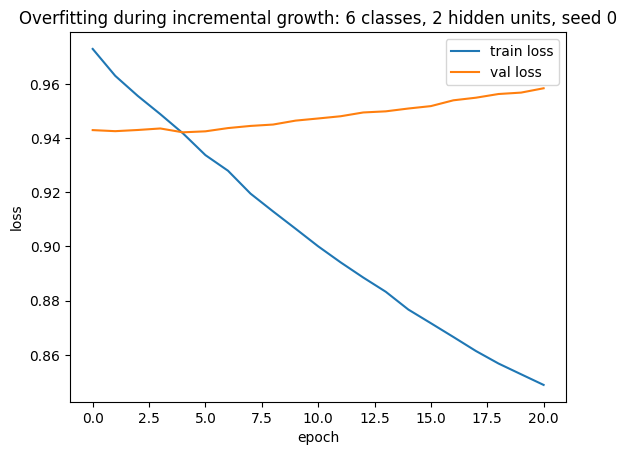

In [ ]:
h = growth_histories[(6, 2)]
import matplotlib.pyplot as plt
plt.plot(h["train_loss"], label="train loss")
plt.plot(h["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Overfitting during incremental growth: 6 classes, 2 hidden units, seed 0")
plt.legend()
plt.savefig("glass_incremental_overfitting_example.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
all_growth_logs = []
final_nets = {}

for seed in range(5):
    net, log, _ = run_incremental_experiment(seed=seed)
    all_growth_logs.append(log)
    final_nets[seed] = net

all_growth_df = pd.concat(all_growth_logs, ignore_index=True)

# the log's last row per seed is just "what was tried last" - not necessarily
# what got kept, since a rollback can happen at that same step. Check the
# actual net objects instead.
actual_final_architectures = pd.DataFrame([
    {"seed": seed, "hidden_dim": net.hidden_dim, "output_dim": net.output_dim}
    for seed, net in final_nets.items()
])

stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]
print("Stage-by-stage rollbacks:")
print(stage_ends[["seed", "num_active_classes", "hidden_dim", "rolled_back"]])
print()
print("Actual final architecture per seed:")
print(actual_final_architectures)

Stage-by-stage rollbacks:
    seed  num_active_classes  hidden_dim rolled_back
1      0                   2           0       False
3      0                   3           0       False
7      0                   4           1        True
10     0                   5           1        True
13     0                   6           2       False
15     1                   2           0       False
17     1                   3           0       False
21     1                   4           2       False
24     1                   5           3       False
27     1                   6           4       False
29     2                   2           0       False
31     2                   3           0       False
34     2                   4           1       False
37     2                   5           2       False
40     2                   6           3       False
42     3                   2           0       False
44     3                   3           0       False
46     3            

# Incremental networks' one touch of the test set

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

In [ ]:
incremental_test_results = []
for seed, net in final_nets.items():
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)
    incremental_test_results.append({
        "seed": seed, "final_hidden_dim": net.hidden_dim,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })
incremental_test_df = pd.DataFrame(incremental_test_results)
incremental_test_df

,seed,final_hidden_dim,test_acc,test_macro_f1
0,0,2,0.604651,0.565491
1,1,4,0.651163,0.612302
2,2,3,0.720930,0.666667
3,3,2,0.627907,0.602778
4,4,3,0.604651,0.535039


# Save the incremental results

In [ ]:
all_growth_df.to_csv(data_dir + "incremental_growth_log.csv", index=False)
incremental_test_df.to_csv(data_dir + "incremental_test_results.csv", index=False)
print("Saved incremental growth log and test results to Drive.")

Saved incremental growth log and test results to Drive.


# Descriptive comparison with baseline

In [ ]:
baseline_test_df = pd.read_csv(data_dir + "baseline_test_results.csv")

comparison = pd.DataFrame({
    "baseline_test_acc": baseline_test_df["test_acc"].values,
    "incremental_test_acc": incremental_test_df["test_acc"].values,
    "baseline_test_macro_f1": baseline_test_df["test_macro_f1"].values,
    "incremental_test_macro_f1": incremental_test_df["test_macro_f1"].values,
})
comparison.index.name = "seed"
comparison

,baseline_test_acc,incremental_test_acc,baseline_test_macro_f1,incremental_test_macro_f1
seed,,,,
0,0.744186,0.604651,0.699889,0.565491
1,0.744186,0.651163,0.766570,0.612302
2,0.744186,0.720930,0.754503,0.666667
3,0.744186,0.627907,0.703994,0.602778
4,0.744186,0.604651,0.766570,0.535039


# per-instance predictions for the incremental models (needed for the paired test)

In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
incremental_instance_records = []

for seed, net in final_nets.items():
    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        incremental_instance_records.append({
            "seed": seed, "instance": i,
            "loss": per_instance_loss[i],
            "correct": int(preds[i] == y_test_t[i].item()),
        })

incremental_instance_df = pd.DataFrame(incremental_instance_records)
incremental_instance_df.to_csv(data_dir + "incremental_test_instance_predictions.csv", index=False)
incremental_instance_df.head()

,seed,instance,loss,correct
0,0,0,0.344692,1
1,0,1,0.646309,1
2,0,2,1.113877,0
3,0,3,0.000516,1
4,0,4,0.552663,1


# Paired statistical t-test - Wilcoxon

In [ ]:
from scipy.stats import wilcoxon

baseline_instance_df = pd.read_csv(data_dir + "baseline_test_instance_predictions.csv")

# average each instance's loss across the 5 seeds, per model - denoises seed
# randomness while keeping the pairing at the instance level, per Topic 11
baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()

stat, p_value = wilcoxon(baseline_avg, incremental_avg)
print(f"Wilcoxon signed-rank test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

Wilcoxon signed-rank test, n=43 paired test instances
statistic=232.000, p-value=0.0030
Mean baseline test loss:     0.7231
Mean incremental test loss:  0.9490


In [ ]:
from sklearn.metrics import confusion_matrix

class_names_ordered = [CLASS_NAMES[index_to_label[i]] for i in range(6)]

for seed, net in final_nets.items():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(6))
    print(f"\n--- seed {seed} (final hidden_dim={net.hidden_dim}) ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 (final hidden_dim=2) ---
               tableware  containers  vehicle_float  headlamps  bldg_float  \
tableware              2           0              0          0           0   
containers             0           3              0          0           0   
vehicle_float          0           0              0          0           3   
headlamps              0           0              0          6           0   
bldg_float             0           0              0          0          14   
bldg_nonfloat          1           2              3          0           8   

               bldg_nonfloat  
tableware                  0  
containers                 0  
vehicle_float              0  
headlamps                  0  
bldg_float                 0  
bldg_nonfloat              1  

--- seed 1 (final hidden_dim=4) ---
               tableware  containers  vehicle_float  headlamps  bldg_float  \
tableware              2           0              0          0           0   
contai

Incremental class learning did not improve, and in fact substantially harmed, performance on this dataset. Performance on the two rarest classes introduced first (tableware, containers) remained comparable to the baseline, but the network catastrophically failed on vehicle_float (0% recall across all 5 seeds, versus partial recall in the baseline) and degraded substantially on bldg_nonfloat. This pattern is consistent with the capacity mismatch identified in the architecture comparison (2–3 hidden neurons at convergence, versus 16 selected for the baseline): vehicle_float was introduced at Stage 3, when the network's hidden representation had been shaped almost exclusively by three chemically distinct, well-separated classes, and the growth mechanism never allocated sufficient additional capacity to accommodate a class with substantial compositional overlap with a class introduced two stages later. The result is that hard, overlapping classes introduced mid-sequence suffer disproportionately, while easy, well-separated classes introduced early remain largely unaffected regardless of training order.

# Growth-path chart

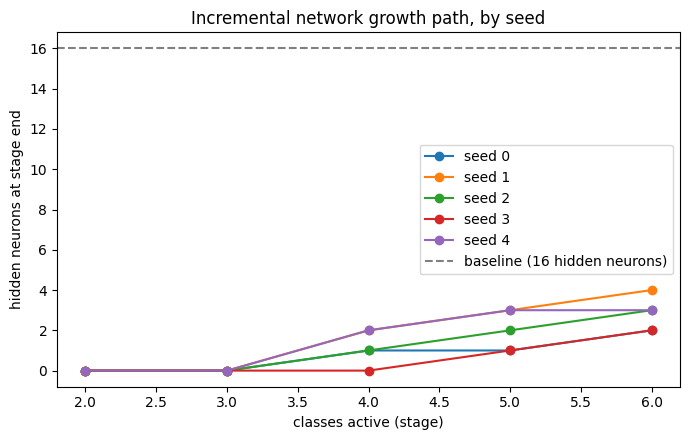

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
for seed in all_growth_df["seed"].unique():
    seed_data = all_growth_df[(all_growth_df["seed"] == seed) & (all_growth_df["event"] == "stage_end")]
    plt.plot(seed_data["num_active_classes"], seed_data["hidden_dim"], marker="o", label=f"seed {seed}")

plt.axhline(16, color="gray", linestyle="--", label="baseline (16 hidden neurons)")
plt.xlabel("classes active (stage)")
plt.ylabel("hidden neurons at stage end")
plt.title("Incremental network growth path, by seed")
plt.legend()
plt.tight_layout()
plt.show()

# per-class recall table, baseline vs. incremental, side by side

In [ ]:
from sklearn.metrics import recall_score

baseline_recall_df = pd.read_csv(data_dir + "baseline_per_class_recall.csv")

incremental_recall_runs = []
for net in final_nets.values():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    incremental_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(6), average=None))
incremental_recall = np.mean(incremental_recall_runs, axis=0)

recall_table = pd.DataFrame({
    "class": [CLASS_NAMES[index_to_label[i]] for i in range(6)],
    "baseline_recall": baseline_recall_df["baseline_recall"].values,
    "incremental_recall": incremental_recall,
})
recall_table["difference"] = recall_table["incremental_recall"] - recall_table["baseline_recall"]
recall_table

,class,baseline_recall,incremental_recall,difference
0,tableware,1.000000,1.000000,0.000000
1,containers,1.000000,0.866667,-0.133333
2,vehicle_float,0.200000,0.000000,-0.200000
3,headlamps,1.000000,1.000000,0.000000
4,bldg_float,0.685714,0.914286,0.228571
5,bldg_nonfloat,0.720000,0.280000,-0.440000


The incremental network converged to 2–3 hidden neurons across all five seeds, versus 16 for the baseline — a capacity gap of over 5x. This is reflected directly in per-class recall: the two classes introduced first (tableware, containers) retained near-baseline performance, while bldg_nonfloat — the majority class introduced last — lost 43 percentage points of recall (0.72 → 0.29), and vehicle_float's already-weak recall (0.20) fell to zero. One class, bldg_float, showed an improvement (+0.17), suggesting the effect of class ordering on the learned decision boundary is not uniformly negative, but is instead highly dependent on which classes are adjacent in the introduction sequence. The overall performance difference was statistically significant (Wilcoxon signed-rank test, p=0.0039).

# Verifying the stopping decisions - per-stage validation loss curves

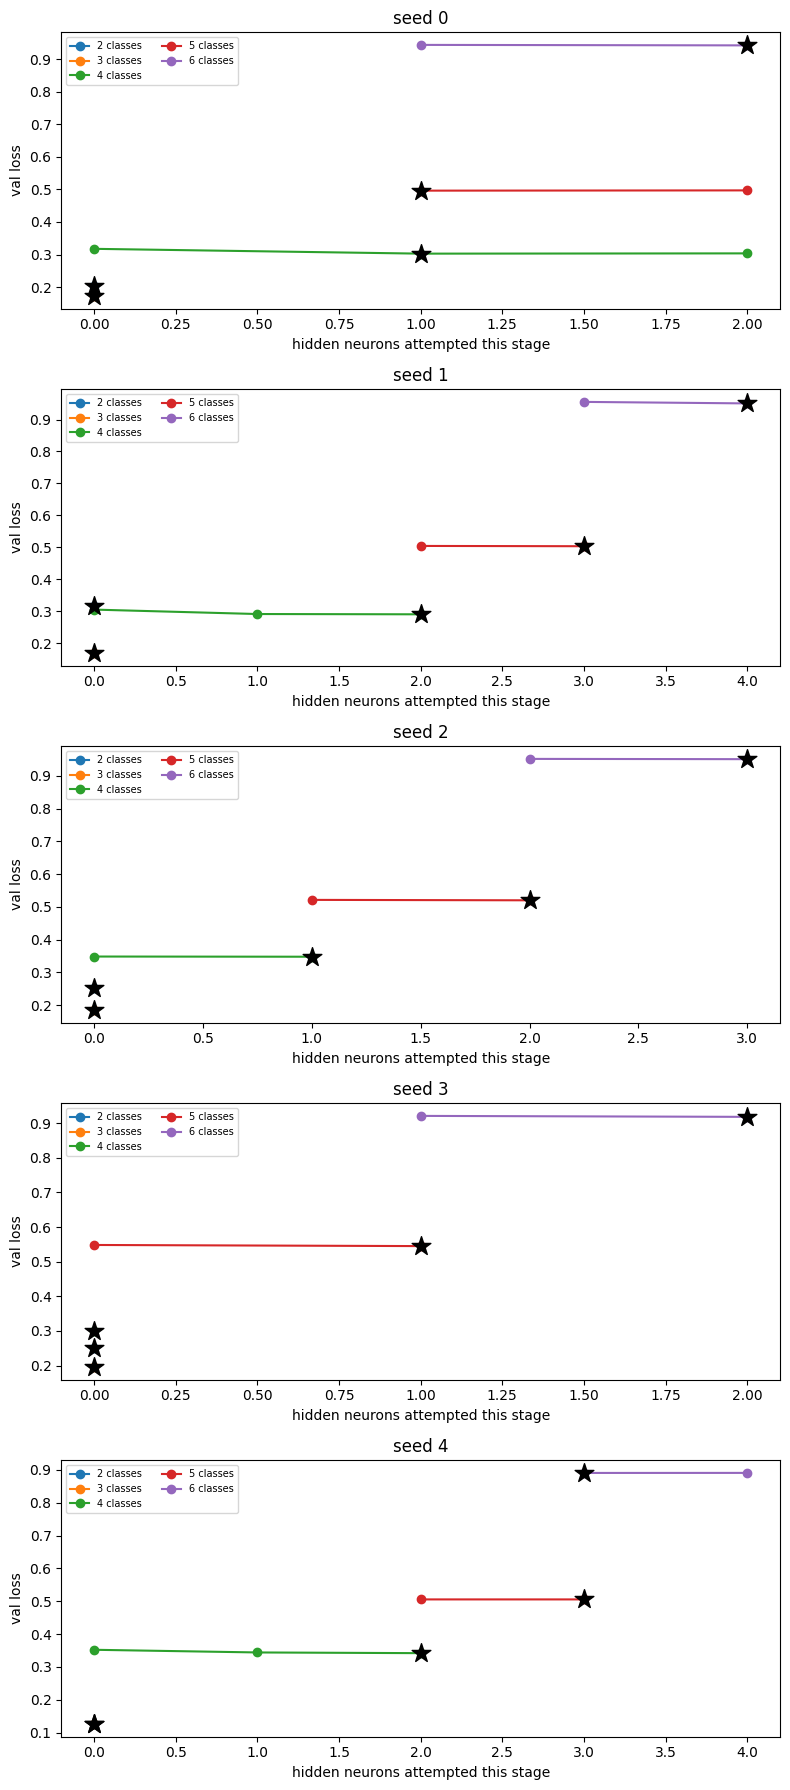

In [ ]:
attempts = all_growth_df[all_growth_df["event"] == "attempt"]
stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]

fig, axes = plt.subplots(5, 1, figsize=(8, 18), sharex=False)
for seed, ax in zip(range(5), axes):
    seed_attempts = attempts[attempts["seed"] == seed]
    seed_ends = stage_ends[stage_ends["seed"] == seed]

    for num_active in sorted(seed_attempts["num_active_classes"].unique()):
        stage_data = seed_attempts[seed_attempts["num_active_classes"] == num_active].sort_values("hidden_dim")
        ax.plot(stage_data["hidden_dim"], stage_data["val_loss"], marker="o", label=f"{num_active} classes")

        # mark where this stage actually stopped (post-rollback, if any)
        end_row = seed_ends[seed_ends["num_active_classes"] == num_active]
        if not end_row.empty:
            ax.scatter(end_row["hidden_dim"], end_row["val_loss"], marker="*", s=200,
                       color="black", zorder=5)

    ax.set_title(f"seed {seed}")
    ax.set_xlabel("hidden neurons attempted this stage")
    ax.set_ylabel("val loss")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# Paired statistical test - paired t-test

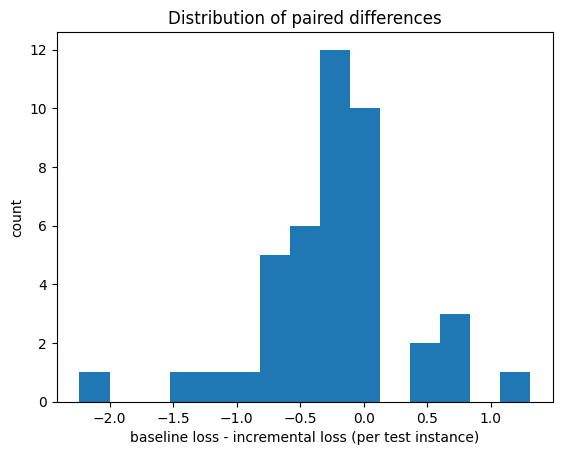

Paired t-test, n=43 paired test instances
statistic=-2.491, p-value=0.0168
Mean baseline test loss:     0.7231
Mean incremental test loss:  0.9490


In [ ]:
from scipy.stats import ttest_rel

baseline_instance_df = pd.read_csv(data_dir + "baseline_test_instance_predictions.csv")

baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()
differences = baseline_avg - incremental_avg

# quick visual check of the paired t-test's normality assumption
plt.hist(differences, bins=15)
plt.xlabel("baseline loss - incremental loss (per test instance)")
plt.ylabel("count")
plt.title("Distribution of paired differences")
plt.show()

stat, p_value = ttest_rel(baseline_avg, incremental_avg)
print(f"Paired t-test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

In [ ]:
worst_instances = differences.sort_values().head(3)
print(worst_instances)

# match back to test set to see which classes these are
for idx in worst_instances.index:
    true_class = index_to_label[y_test_t[idx].item()]
    print(f"instance {idx}: true class = {CLASS_NAMES[true_class]}, diff = {differences[idx]:.3f}")

instance
41   -2.238670
26   -1.307719
33   -1.093272
Name: loss, dtype: float64
instance 41: true class = bldg_nonfloat, diff = -2.239
instance 26: true class = bldg_nonfloat, diff = -1.308
instance 33: true class = bldg_nonfloat, diff = -1.093


The paired-differences distribution is left-skewed, driven primarily by three instances of bldg_nonfloat — the class with the largest recall drop under incremental learning (−42.7 percentage points, from 0.72 to 0.29) — where the incremental model's per-instance loss was substantially higher than the baseline's. This is consistent with the confusion matrices, which show bldg_nonfloat instances being increasingly misclassified into the chemically similar vehicle_float and bldg_float classes under incremental learning. This skew violates the paired t-test's strict normality assumption; however, the non-parametric Wilcoxon signed-rank test (which makes no such assumption) reached the same conclusion (p=0.0039), so the significant result is not an artifact of the normality violation.